# Jaiswal-Banka local-pattern EEG features

This notebook validates LNDP and 1D-LGP against Figures 3 and 4 of Jaiswal and Banka (2017), compares the 1D-LBP baseline, and demonstrates per-channel histograms on one canonical `Data_Pattern/patt` imagery block.

The transfer is methodological only: applying single-channel seizure-benchmark patterns independently to 63 imagery channels does not reproduce the paper's classification results.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-eeg-local-patterns")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from features import (
    compute_lbp_codes,
    compute_lgp_codes,
    compute_lndp_codes,
    extract_local_pattern_features,
    load_feature_config,
    prepare_feature_windows,
)
from utils.datasets import NumpyDataset

TOKENS = {
    "surface": "#FCFCFD",
    "panel": "#FFFFFF",
    "ink": "#1F2430",
    "muted": "#6F768A",
    "grid": "#E6E8F0",
    "axis": "#D7DBE7",
    "blue": "#A3BEFA",
    "blue_dark": "#2E4780",
    "gold": "#FFE15B",
    "gold_dark": "#736422",
    "orange": "#F0986E",
}
plt.rcParams.update({
    "figure.facecolor": TOKENS["surface"],
    "axes.facecolor": TOKENS["panel"],
    "axes.edgecolor": TOKENS["axis"],
    "axes.labelcolor": TOKENS["ink"],
    "axes.titlecolor": TOKENS["ink"],
    "xtick.color": TOKENS["muted"],
    "ytick.color": TOKENS["muted"],
    "grid.color": TOKENS["grid"],
    "font.family": "DejaVu Sans",
})

def block_map(blocks):
    return {block.name: block for block in blocks}

def add_header(ax, title, subtitle):
    ax.set_title(title, loc="left", fontsize=12, fontweight="semibold", pad=24)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, ha="left", va="bottom", fontsize=8.5, color=TOKENS["muted"])
    ax.spines[["top", "right"]].set_visible(False)

CONFIG = load_feature_config(overrides={"feature_groups": ["local_patterns"]})
CONFIG

FeatureExtractionConfig(analysis_sfreq=125.0, crop_start_seconds=0.5, crop_end_seconds=15.5, window_seconds=None, window_stride_seconds=None, dtype='float32', feature_groups=('local_patterns',), frequency_bands=(FrequencyBand(name='delta', f_min=2.0, f_max=4.0), FrequencyBand(name='theta', f_min=4.0, f_max=8.0), FrequencyBand(name='alpha', f_min=8.0, f_max=13.0), FrequencyBand(name='beta', f_min=13.0, f_max=30.0), FrequencyBand(name='low_gamma', f_min=30.0, f_max=40.0)), histogram_mode='probability', local_pattern_neighbors=8, transform_eog=False, filter_hz=None, notch_hz=None, reference=None, normalization='none')

## Published examples

The implementation uses complete neighborhoods only. For `m=8`, every code consumes nine chronological samples, with `P0` on the right and assigned to bit zero.

In [2]:
lndp_segment = np.array([50, 35, 32, 18, 10, 3, 4, 8, 12], dtype=np.float64)
lgp_segment = np.array([50, 35, 32, 18, 10, 3, -1, -5, -6], dtype=np.float64)

paper_codes = pd.DataFrame({
    "method": ["LNDP, Fig. 3", "1D-LGP, Fig. 4"],
    "expected_code": [7, 224],
    "computed_code": [
        int(compute_lndp_codes(lndp_segment, neighbors=8)[0]),
        int(compute_lgp_codes(lgp_segment, neighbors=8)[0]),
    ],
})
assert paper_codes["expected_code"].equals(paper_codes["computed_code"])
paper_codes

,method,expected_code,computed_code
0,"LNDP, Fig. 3",7,7
1,"1D-LGP, Fig. 4",224,224


## Synthetic structural comparison

LNDP and 1D-LGP are invariant to a global offset. The plot shows their most frequent codes alongside 1D-LBP for a repeated, noisy motif.

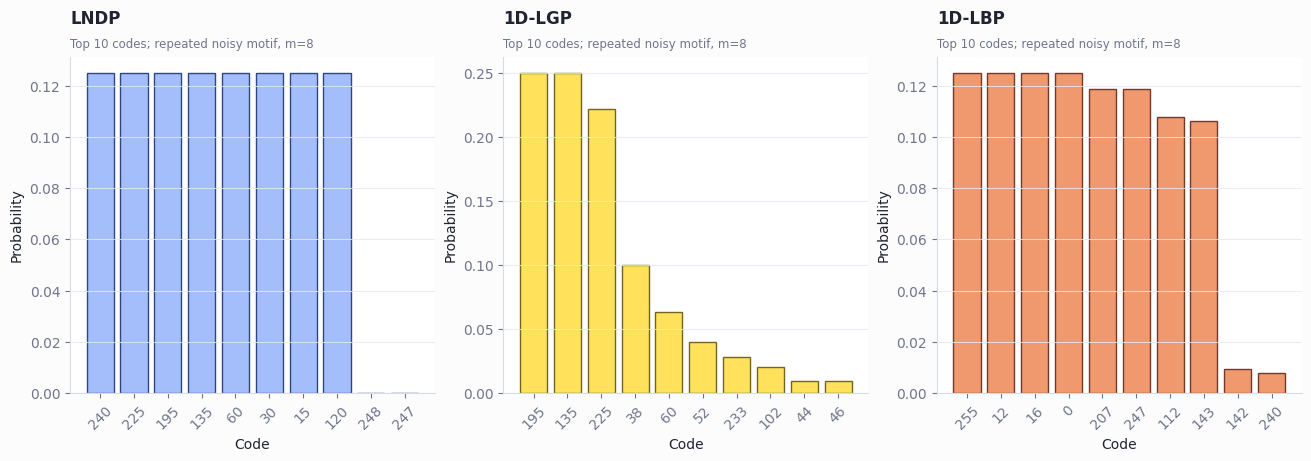

In [3]:
rng = np.random.default_rng(2026)
motif = np.array([0.0, 1.0, 2.5, 1.5, 0.2, -1.0, -2.0, -0.8], dtype=np.float64)
synthetic_signal = np.tile(motif, 80) + 0.08 * rng.normal(size=motif.size * 80)
offset_signal = synthetic_signal + 25.0

code_functions = {
    "LNDP": compute_lndp_codes,
    "1D-LGP": compute_lgp_codes,
    "1D-LBP": compute_lbp_codes,
}
synthetic_histograms = {}
for name, function in code_functions.items():
    codes = function(synthetic_signal, neighbors=8)
    offset_codes = function(offset_signal, neighbors=8)
    np.testing.assert_array_equal(codes, offset_codes)
    synthetic_histograms[name] = np.bincount(codes, minlength=256) / codes.size

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), constrained_layout=True)
colors = [TOKENS["blue"], TOKENS["gold"], TOKENS["orange"]]
edges = [TOKENS["blue_dark"], TOKENS["gold_dark"], "#713A2B"]
for ax, (name, histogram), color, edge in zip(axes, synthetic_histograms.items(), colors, edges, strict=True):
    top_codes = np.argsort(histogram)[-10:][::-1]
    ax.bar(np.arange(top_codes.size), histogram[top_codes], color=color, edgecolor=edge)
    ax.set_xticks(np.arange(top_codes.size), top_codes, rotation=45)
    ax.set_xlabel("Code")
    ax.set_ylabel("Probability")
    ax.grid(axis="y", alpha=0.8)
    add_header(ax, name, "Top 10 codes; repeated noisy motif, m=8")
plt.show()

## Canonical imagery block

Histograms are computed independently for each EEG channel after crop `[0.5, 15.5)` and resampling to 125 Hz. Probability mode keeps histogram mass comparable between full epochs and shorter windows.

In [4]:
imagery_dataset = NumpyDataset(
    PROJECT_ROOT / "data" / "Data_Pattern",
    dataset_step_type="patt",
    cache_policy="disk",
)
imagery_sample = imagery_dataset[1, 1, 1]

full_windows = prepare_feature_windows(
    imagery_sample.eeg,
    source_sfreq=imagery_sample.sfreq,
    config=CONFIG,
)
full_blocks = extract_local_pattern_features(full_windows, config=CONFIG)
full = block_map(full_blocks)

window_config = load_feature_config(overrides={
    "feature_groups": ["local_patterns"],
    "window_seconds": 5.0,
    "window_stride_seconds": 2.0,
})
windowed_windows = prepare_feature_windows(
    imagery_sample.eeg,
    source_sfreq=imagery_sample.sfreq,
    config=window_config,
)
windowed_blocks = extract_local_pattern_features(windowed_windows, config=window_config)
windowed = block_map(windowed_blocks)

real_summary = pd.DataFrame({
    "source_key": ["(1, 1, 1)"],
    "recording_family": ["Data_Pattern/patt"],
    "channels": [len(imagery_sample.eeg_channels)],
    "full_shape": [full["lndp"].values.shape],
    "windowed_shape": [windowed["lndp"].values.shape],
    "first_window_seconds": [windowed_windows.bounds_seconds[0].tolist()],
    "last_window_seconds": [windowed_windows.bounds_seconds[-1].tolist()],
})
real_summary

,source_key,recording_family,channels,full_shape,windowed_shape,first_window_seconds,last_window_seconds
0,"(1, 1, 1)",Data_Pattern/patt,63,"(1, 63, 256)","(6, 63, 256)","[0.5, 5.5]","[10.5, 15.5]"


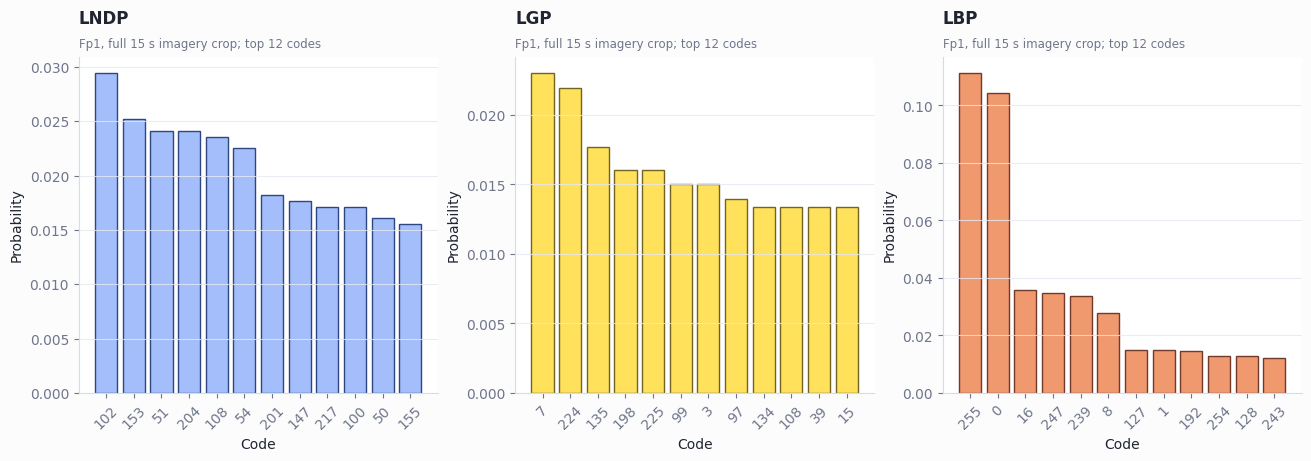

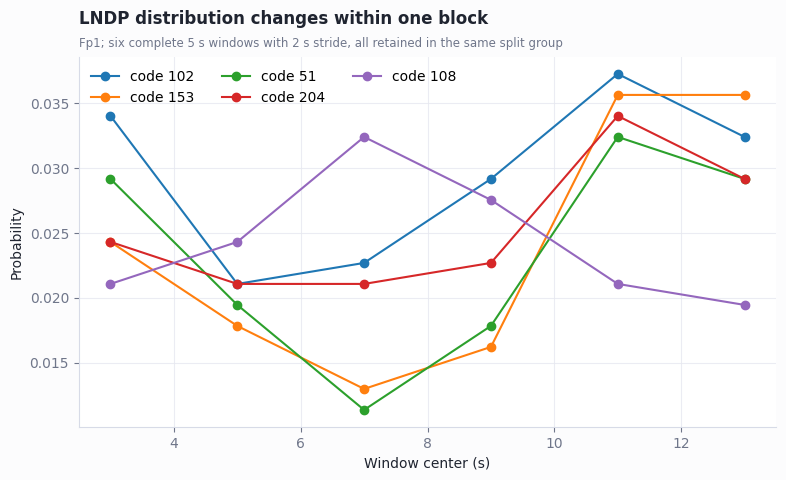

LOCAL_PATTERNS_VERIFIED


In [5]:
fp1_index = imagery_sample.eeg_channels.index("Fp1")
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), constrained_layout=True)
for ax, name, color, edge in zip(axes, ("lndp", "lgp", "lbp"), colors, edges, strict=True):
    histogram = full[name].values[0, fp1_index]
    top_codes = np.argsort(histogram)[-12:][::-1]
    ax.bar(np.arange(top_codes.size), histogram[top_codes], color=color, edgecolor=edge)
    ax.set_xticks(np.arange(top_codes.size), top_codes, rotation=45)
    ax.set_xlabel("Code")
    ax.set_ylabel("Probability")
    ax.grid(axis="y", alpha=0.8)
    add_header(ax, name.upper(), "Fp1, full 15 s imagery crop; top 12 codes")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.8))
full_lndp = full["lndp"].values[0, fp1_index]
selected_codes = np.argsort(full_lndp)[-5:][::-1]
centers = windowed_windows.bounds_seconds.mean(axis=1)
for code in selected_codes:
    ax.plot(centers, windowed["lndp"].values[:, fp1_index, code], marker="o", label=f"code {code}")
ax.set_xlabel("Window center (s)")
ax.set_ylabel("Probability")
ax.grid(alpha=0.8)
ax.legend(frameon=False, ncol=3)
add_header(ax, "LNDP distribution changes within one block", "Fp1; six complete 5 s windows with 2 s stride, all retained in the same split group")
plt.show()

for block in (*full_blocks, *windowed_blocks):
    assert np.isfinite(block.values).all()
    np.testing.assert_allclose(block.values.sum(axis=-1), 1.0, atol=1e-6)
assert all(block.values.shape == (1, 63, 256) for block in full_blocks)
assert all(block.values.shape == (6, 63, 256) for block in windowed_blocks)
print("LOCAL_PATTERNS_VERIFIED")